 # **Relationship Between Eating Habits and Obesity**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
from scipy.stats import chi2_contingency

In [2]:
df = pd.read_csv('../../Data/Cleaned_Obesity_DataSet.csv')

## **Correlation between Vegetables Consumptions (FCVC) and Obesity Levels**

The **Chi-Square test** is used to analyze the correlation between Vegetable Consumption(FCVC) and Obesity Levels (NObeyesdad). <br><br>
**Hypothesis Statement**  
- **Null Hypothesis (H₀):** There is no significant association between FCVC and Obesity Level.  
- **Alternative Hypothesis (H₁):** There is a significant association between FCVC and Obesity Level.  

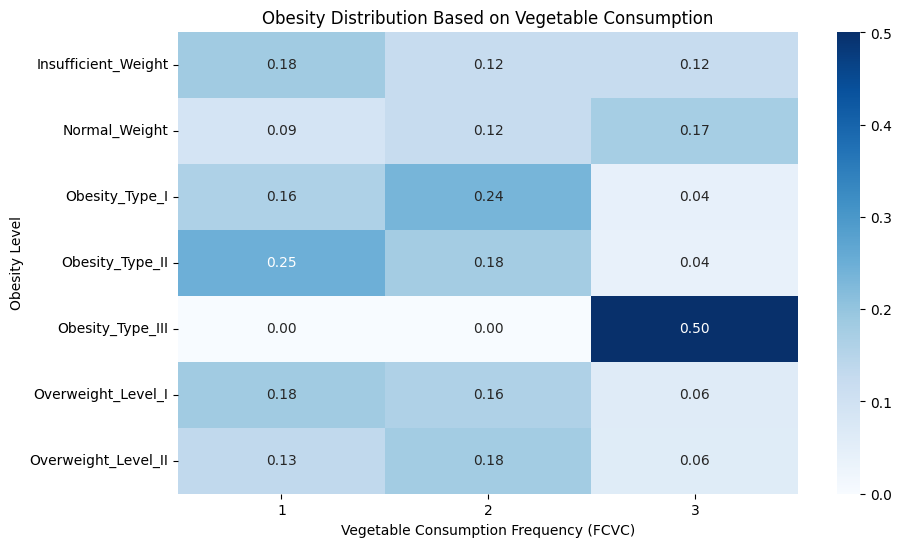

In [3]:
# Create a crosstab table (transposed) to analyze obesity distribution by FCVC
crosstab = pd.crosstab(df["FCVC"], df["NObeyesdad"], normalize="index").T

# Visualize the data using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(crosstab, cmap="Blues", annot=True, fmt=".2f")  # Add annotations for clarity

# Set plot title and axis labels
plt.title("Obesity Distribution Based on Vegetable Consumption")
plt.xlabel("Vegetable Consumption Frequency (FCVC)")
plt.ylabel("Obesity Level")

# Adjust axis label rotation for better readability
plt.yticks(rotation=0)  
plt.xticks(rotation=0)  

# Display the plot
plt.show()

Chi-Square Statistic: 990.0218
P-Value: 0.0000
Degrees of Freedom: 12


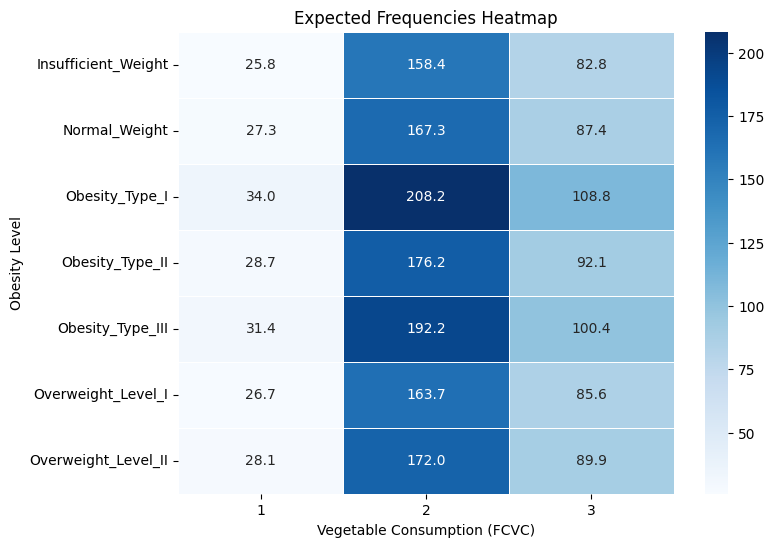

Conclusion: There is a significant relationship between FCVC and obesity level (Reject H0).


In [4]:
# Create a contingency table for FCVC and obesity level
contingency_table = pd.crosstab(df["FCVC"], df["NObeyesdad"])

# Perform Chi-Square test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

# Print Chi-Square test results
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")

# Visualize expected frequencies with a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns).T, 
            annot=True, cmap="Blues", fmt=".1f", linewidths=0.5)

plt.title("Expected Frequencies Heatmap")
plt.xlabel("Vegetable Consumption (FCVC)")
plt.ylabel("Obesity Level")
plt.show()

# Interpretation
alpha = 0.05
if p < alpha:
    print("Conclusion: There is a significant relationship between FCVC and obesity level (Reject H0).")
else:
    print("Conclusion: No significant relationship between FCVC and obesity level (Fail to reject H0).")

#### **Results**  
- **Chi-Square Statistic:** 990.0218  
- **Degrees of Freedom (df):** 12  
- **P-Value:** 0.0000  

#### **Conclusion**  
- Since the p-value is **0.0000** (which is **< 0.05**), we **reject H₀**.  
-  This indicates a **strong association** between vegetable consumption and obesity levels.  

This finding is quite intriguing because we typically assume that higher vegetable consumption should correlate with lower obesity risk. However, the data suggests that many individuals who frequently consume vegetables still fall into **Obesity Type III**.  

***Correlation does not imply causation** – while there is a statistical relationship, it does not necessarily mean that vegetable consumption directly influences obesity levels. Investigating **other variables** may help explain why some high vegetable consumers still experience severe obesity. Further analysis could uncover more meaningful patterns in the data.  

To gain deeper insights, I will conduct **further analysis between FCVC (Frequency of Vegetable Consumption) and FAVC (Frequency of Consumption of High-Calorie Food)**. This will help determine whether individuals who consume vegetables frequently also tend to consume high-calorie foods, which could be a key factor influencing obesity levels.


#### **Contingency Table of Vegetable Consumption (FCVC) and High-Calorie Food Consumption (FAVC)**

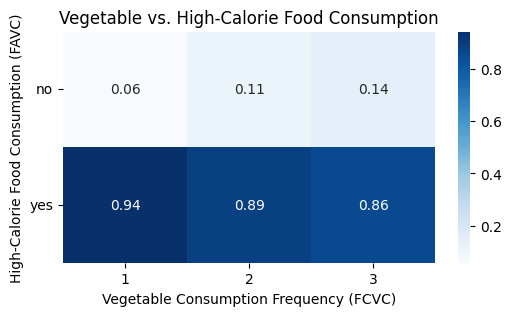

In [5]:
# Buat crosstab table dengan nama variabel baru untuk menghindari konflik
crosstab_fcvc_favc = pd.crosstab(df["FCVC"], df["FAVC"], normalize="index").T

# Visualisasi heatmap
plt.figure(figsize=(6, 3))
sns.heatmap(crosstab_fcvc_favc, cmap="Blues", annot=True, fmt=".2f")  # Menampilkan nilai proporsi

# Set judul dan label sumbu
plt.title("Vegetable vs. High-Calorie Food Consumption")
plt.xlabel("Vegetable Consumption Frequency (FCVC)")
plt.ylabel("High-Calorie Food Consumption (FAVC)")

# Atur rotasi label agar lebih mudah dibaca
plt.yticks(rotation=0)
plt.xticks(rotation=0)

# Tampilkan plot
plt.show()

In [6]:
# Create a contingency table for FCVC and FAVC
contingency_table = pd.crosstab(df["FCVC"], df["FAVC"])

# Perform Chi-Square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Calculate Cramér's V
n = contingency_table.sum().sum()  # Total sample size
cramers_v = np.sqrt(chi2 / (n * min(contingency_table.shape) - 1))

# Print results
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"Cramér's V: {cramers_v:.4f}")

# Interpretation
alpha = 0.05
if p < alpha:
    print("Conclusion: There is a significant relationship between FCVC and FAVC (Reject H0).")
else:
    print("Conclusion: No significant relationship between FCVC and FAVC (Fail to reject H0).")


Chi-Square Statistic: 11.3715
P-Value: 0.0034
Degrees of Freedom: 2
Cramér's V: 0.0522
Conclusion: There is a significant relationship between FCVC and FAVC (Reject H0).


The heatmap shows that most individuals with high vegetable consumption (FCVC) also consume high-calorie food (FAVC), with probabilities of 94%, 89%, and 86% for FCVC levels 1, 2, and 3, respectively. The Chi-Square test confirms a significant relationship (**χ² = 11.37, p = 0.0034, Cramér's V = 0.0522**), indicating that higher vegetable intake does not necessarily mean avoiding high-calorie foods. This may contribute to the observed correlation between FCVC and obesity levels.

## **Correlation Between high-calorie food (FAVC) and Obesity Level**

#### **High-Calorie Food Consumption (FAVC) and Obesity Levels (NObeyesdad)**

The **Chi-Square test** is used to analyze the correlation between **High-Calorie Food Consumption (FAVC)** and **Obesity Levels (NObeyesdad).**  

#### **Hypothesis Statement**
- **Null Hypothesis (H₀):** There is no significant association between **FAVC** and **Obesity Level**.  
- **Alternative Hypothesis (H₁):** There is a significant association between **FAVC** and **Obesity Level**.  


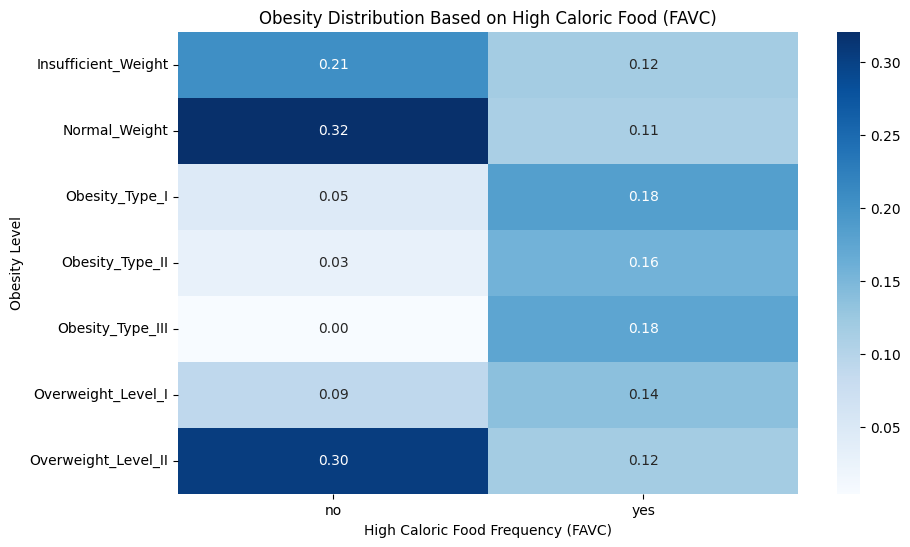

In [7]:
# Create a crosstab table (transposed) to analyze obesity distribution by FCVC
crosstab = pd.crosstab(df["FAVC"], df["NObeyesdad"], normalize="index").T

# Visualize the data using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(crosstab, cmap="Blues", annot=True, fmt=".2f")  # Add annotations for clarity

# Set plot title and axis labels
plt.title("Obesity Distribution Based on High Caloric Food (FAVC)")
plt.xlabel("High Caloric Food Frequency (FAVC)")
plt.ylabel("Obesity Level")

# Adjust axis label rotation for better readability
plt.yticks(rotation=0)  
plt.xticks(rotation=0)  

# Display the plot
plt.show()

Chi-Square Statistic: 231.2762
P-Value: 0.0000
Degrees of Freedom: 6
Cramér's V: 0.3329


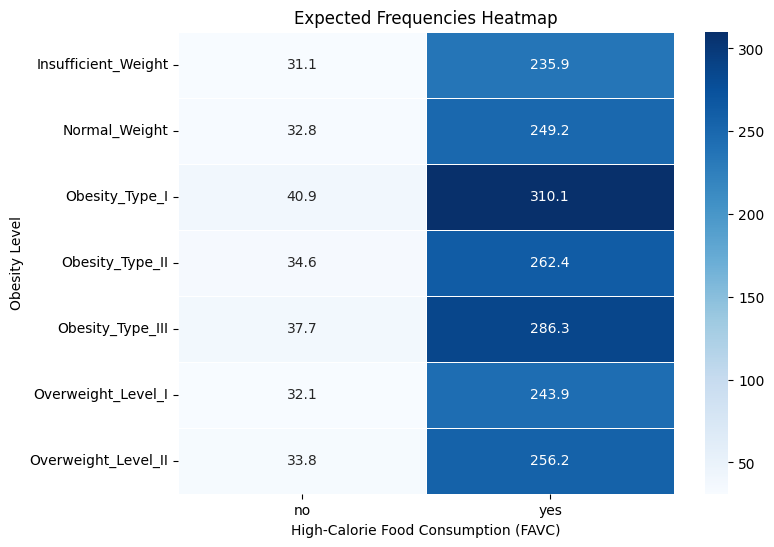

Conclusion: There is a significant relationship between FAVC and obesity level (Reject H0).


In [8]:
# Create a contingency table for FAVC and obesity level
contingency_table = pd.crosstab(df["FAVC"], df["NObeyesdad"])

# Perform Chi-Square test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

# Compute Cramér's V for effect size
n = contingency_table.sum().sum()  # Total sample size
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))

# Print Chi-Square test results
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"Cramér's V: {cramers_v:.4f}")

# Visualize expected frequencies with a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns).T, 
            annot=True, cmap="Blues", fmt=".1f", linewidths=0.5)

plt.title("Expected Frequencies Heatmap")
plt.xlabel("High-Calorie Food Consumption (FAVC)")
plt.ylabel("Obesity Level")
plt.show()

# Interpretation
alpha = 0.05
if p < alpha:
    print("Conclusion: There is a significant relationship between FAVC and obesity level (Reject H0).")
else:
    print("Conclusion: No significant relationship between FAVC and obesity level (Fail to reject H0).")


### Conclusion  

The **Chi-Square test** examines whether there is a significant relationship between **high-caloric food consumption (FAVC)** and **obesity levels**. The results are:  

- **Chi-Square Statistic:** 231.2762 → This measures how much the observed data deviates from the expected data under the assumption of no relationship. A higher value suggests a stronger difference.  
- **P-Value:** 0.0000 → This indicates the probability of obtaining these results if there were no real association. Since it's below 0.05, we reject the null hypothesis, meaning there is a significant relationship.  
- **Degrees of Freedom:** 6 → This is determined by the number of categories in each variable and affects the distribution of the test statistic.  
- **Cramér’s V:** 0.3329 → This measures the strength of the association. A value of 0.3–0.5 indicates a **moderate** relationship.  

### Interpretation from the Heatmap  

- **Normal weight is more common** among those who **do not** consume high-caloric food (0.32).  
- **Obesity levels (Type I, II, III) are higher** in those who **do** consume high-caloric food.  
- **Overweight Level II is highest (0.30) among non-consumers**, suggesting other influencing factors.  

### Key Insight  
While **high-caloric food consumption is significantly linked to obesity**, the **moderate effect size (Cramér’s V = 0.3329)** suggests other factors also contribute (e.g., physical activity, genetics, overall diet).  
